In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import json
import glob
import pickle


In [330]:
participant_id = '024'
condition = 'RW'

# load fnirs data from offlineml/data
fnirs_data_path = os.path.join(os.environ.get("HOME", ""),
    '/Users/juliasantaniello/Desktop/OfflineNeuroloop/data/', f'{participant_id}_processed_{condition}.csv')
fnirs_data = pd.read_csv(fnirs_data_path)

# load task data from fnirs-2-rl
try:
    DATA_PATH = os.path.join(os.environ.get("HOME", ""),
                '/Users/juliasantaniello/Desktop/fNIRS-2-RL/Experiment/ParticipantData/')
    assert os.path.exists(os.path.join(DATA_PATH, 'fNIRS/LabeledData/'))
except AssertionError:
    print("Please store path to participant date in DATA_PATH")

# labeled_data_source_folder = os.path.join(DATA_PATH, 'fNIRS/LabeledData/')
rl_taskstats_source_folder = os.path.join(DATA_PATH, 'TaskData/')
search_pattern = os.path.join(rl_taskstats_source_folder, f"{participant_id}_{condition}_*.pickle")
matching_files = glob.glob(search_pattern)

if not matching_files:
    raise FileNotFoundError(f"No task data file found for participant {participant_id} with condition {condition} in {rl_taskstats_source_folder}")
task_data_path = matching_files[0]

with open(task_data_path, 'rb') as f:
    task_data = pickle.load(f)

In [331]:
fnirs_data.head()

,Unnamed: 0,time,MARKER,pid,L_O_DSI,L_D_DSI,L_O_DSphi,L_D_DSphi,R_O_DSI,R_D_DSI,R_O_DSphi,R_D_DSphi,trial_id
0,0,2024-10-02 20:35:00.947058105,TASK_BEGIN,24,-0.257255,-0.222316,2.665194,-0.342881,-0.449717,-0.298546,4.605357,-1.338204,1
1,1,2024-10-02 20:35:01.024701172,0,24,-0.232955,-0.237100,2.743298,-0.334073,-0.451970,-0.308533,4.713882,-1.367429,1
2,2,2024-10-02 20:35:01.092605957,0,24,-0.208989,-0.250270,2.783797,-0.327996,-0.460341,-0.315356,4.807633,-1.394227,1
3,3,2024-10-02 20:35:02.035056152,0,24,-0.185834,-0.261714,2.787142,-0.325609,-0.474103,-0.318991,4.876421,-1.415957,1
4,4,2024-10-02 20:35:02.102926025,0,24,-0.164093,-0.271305,2.755227,-0.327531,-0.492405,-0.319463,4.910841,-1.430475,1


In [332]:
task_data[1]['rewards'][-1]

np.float32(-0.0)

In [333]:
print("Task Start", task_data[0]["dateTimestamps"][1])
print("fNIRS Start", fnirs_data["time"][0])

Task Start 2024-10-02 20:35:03.932201971
fNIRS Start 2024-10-02 20:35:00.947058105


<Axes: >

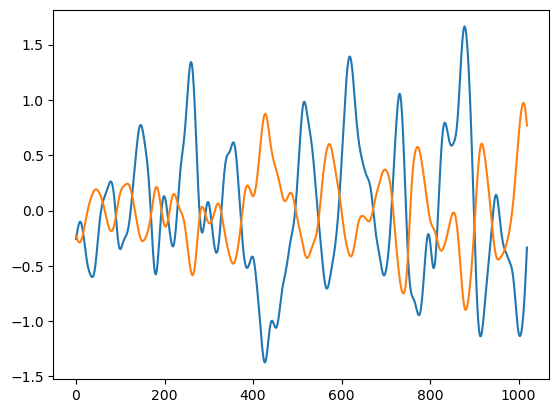

In [334]:
#print fnirs data in one plot
fnirs_data["L_O_DSI"].plot()
fnirs_data["L_D_DSI"].plot()


In [335]:
from scipy.stats import entropy

def KL_divergence(p, q):
    return p * np.log(p / q)
    
def euclidean_distance(p, q):
    return np.sqrt(np.sum((p - q) ** 2))

def get_color(condition, r, r_sum):
    if condition[0] == 'L':
        if r > 25:
            return 'green'  
        elif r > 5:
            return 'yellow'
        else:
            return 'red'
    elif condition[0] == 'R':
        if r > -1:
            return 'green'  
        else:
            return 'red'
    elif condition[0] == 'F':
        if r_sum > 30:
            return 'green'
        elif r_sum > 7:
            return 'yellow'
        else:
            return 'red'



green -8.0
green -5.0
red -75.0
green -13.0
green -7.0
green -13.0
green -9.0
green -13.0
green -6.0
green -8.0
red -75.0
red -75.0
red -75.0
red -75.0
red -75.0
green -13.0
green -10.0
red -75.0
red -75.0
red -75.0
red -75.0
green -20.0
green -6.0
green -7.0
red -75.0
red -75.0
red -75.0
green -16.0
green -13.0
red -75.0
[np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.1001848539239483), np.float64(6.256269858567686), np.float64(5.733032399349557), np.float64(6.487544768251112), np.float64(6.120077460145733), np.float64(0.0), np.float64(0.0), np.float64(6.774306250535364), np.float64(6.197914198533916), np.float64(1.1511173971781605), np.float64(6.730814446772674), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(6.3286162249360025), np.float64(1.1118545226360623), np.float64(5.798636474126463), np.float64(0.0), np.float64(0.0), np.float64

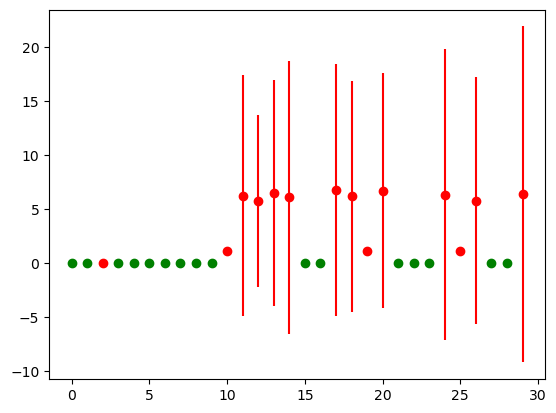

In [336]:
errors = []
errors_std = []
episode_errors = []
colors = []

for episode in task_data:
    for step, _ in enumerate(task_data[episode]['chosen_actions']):
        optimal_action = task_data[episode]['optimal_actions'][step]
        chosen_action = task_data[episode]['chosen_actions'][step]

        if step is None or optimal_action is None or chosen_action is None:
            error = 0
        else:
            error = abs(euclidean_distance(optimal_action, chosen_action))
        episode_errors.append(error)

    #make color whether the agent won or not
    r = task_data[episode]['rewards'][-1]
    r_sum = sum(r for r in task_data[episode]['rewards'] if r is not None)

    color = get_color(condition, r, r_sum)
    colors.append(color)
    
    print(color, r_sum)
    

    errors.append(np.mean(episode_errors))
    errors_std.append(np.var(episode_errors))
    episode_errors = []

print(errors)

#include variance as error bars
for i, (err, err_std, color) in enumerate(zip(errors, errors_std, colors)):
    plt.errorbar(i, err, yerr=err_std, fmt='o', color=color)

plt.show()


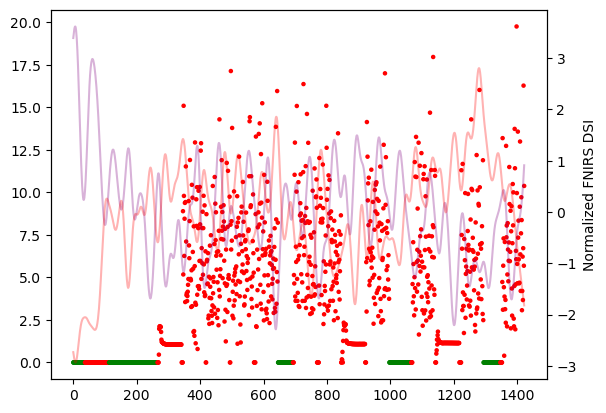

In [337]:
errors = []
errors_std = []
episode_errors = []
colors = []

for episode in task_data:
    #make color whether the agent won or not
    r = task_data[episode]['rewards'][-1]
    r_sum = sum(r for r in task_data[episode]['rewards'] if r is not None)

    color = get_color(condition, r, r_sum)
    for step, _ in enumerate(task_data[episode]['chosen_actions']):
        optimal_action = task_data[episode]['optimal_actions'][step]
        chosen_action = task_data[episode]['chosen_actions'][step]

        if step is None or optimal_action is None or chosen_action is None:
            error = 0
        else:
            error = abs(euclidean_distance(optimal_action, chosen_action))
        episode_errors.append(error)
        colors.append(color)
    
        errors.append(error)

#plor errors with colors
plt.scatter(range(len(errors)), errors, c=colors, s=5)
# Overlay FNIRS data such that it stretches proportionally across the x-axis spanned by 'errors',
# and is shown on a different y-axis (top), ending at the same x as 'errors'.

ax1 = plt.gca()
ax2 = ax1.twinx()  # Create secondary y-axis

# Get the length of errors and fnirs_data
len_errors = len(errors)
len_fnirs = len(fnirs_data)

# Rescale (interpolate) the FNIRS time series to match the errors' x-range
from scipy.interpolate import interp1d
import numpy as np

x_errors = np.arange(len_errors)
x_fnirs = np.linspace(0, len_errors - 1, len_fnirs)

# Interpolation functions for FNIRS signals
lo_interp = interp1d(x_fnirs, fnirs_data["R_O_DSphi"], kind='linear', fill_value="extrapolate")
ld_interp = interp1d(x_fnirs, fnirs_data["R_D_DSphi"], kind='linear', fill_value="extrapolate")

# Interpolated FNIRS values over error axis
lo_values = lo_interp(x_errors)
ld_values = ld_interp(x_errors)

# Optionally normalize for better overlay
lo_norm = (lo_values - np.mean(lo_values)) / np.std(lo_values)
ld_norm = (ld_values - np.mean(ld_values)) / np.std(ld_values)

ax2.plot(x_errors, lo_norm, color='purple', alpha=0.3, label='L_O_DSI (fnirs, norm)')
ax2.plot(x_errors, ld_norm, color='red', alpha=0.3, label='L_D_DSI (fnirs, norm)')
ax2.set_ylabel('Normalized FNIRS DSI')
# ax2.legend(loc='upper right')
plt.show()